In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns


# Data Loading

In [ ]:
df=pd.read_csv("loan_approval_data.csv")

# Data Viewing And Inspection

In [4]:
df.shape
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# Handle missing values

In [5]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["number"]).columns
cat_imp=SimpleImputer(strategy="most_frequent")
num_imp=SimpleImputer(strategy="mean")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])
df.isnull().sum()
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


# Exploratory Data Analysis

C:\Users\Admin\anaconda3\anaconda1\Lib\site-packages\seaborn\categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


<Axes: title={'center': 'Is Loan Approved or Not'}, xlabel='Gender', ylabel='count'>

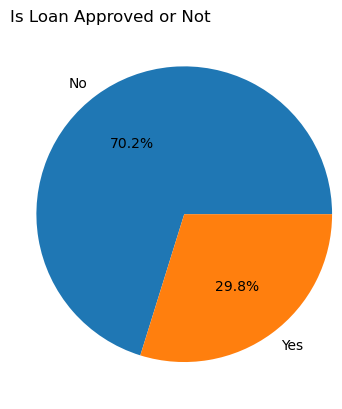

In [6]:
#How balanced our classes are?
class_count=df["Loan_Approved"].value_counts()
plt.pie(class_count,labels=
        ["No","Yes"],autopct="%1.1f%%")
plt.title("Is Loan Approved or Not")
gen_count=df["Gender"].value_counts()
sns.barplot(gen_count)
#ax.bar_label(ax.containers[0])

[Text(0, 0, '621'), Text(0, 0, '379')]

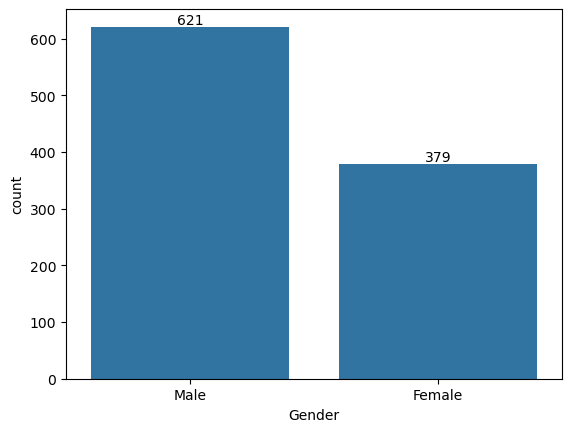

In [7]:
gen_count=df["Gender"].value_counts()
ax=sns.barplot(gen_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

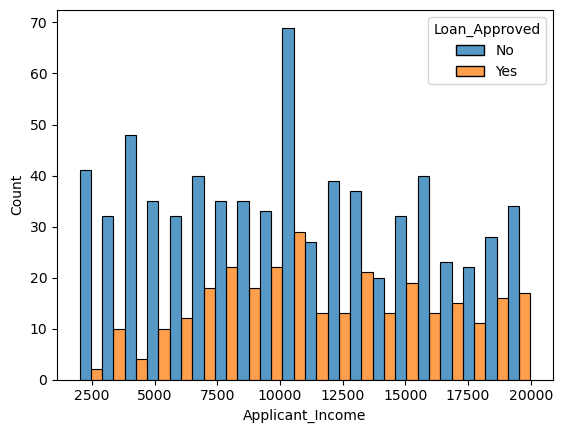

In [8]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

<Axes: xlabel='Credit_Score', ylabel='Count'>

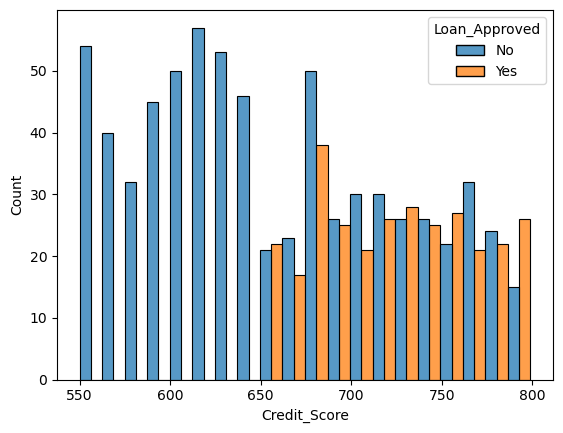

In [9]:
sns.histplot(
    data=df,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

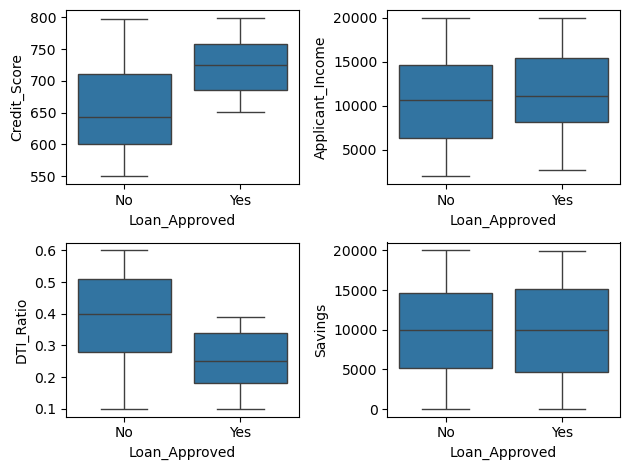

In [41]:
#Outlier Detection-Boxplot
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")
fig.tight_layout()

In [10]:
df=df.drop("Applicant_ID",axis=1)

# Feature Encoding

In [11]:
#Label Encoding -Assign An Int to each category in single colummn According to levels
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

#One Hot Encoding -creates binary columns for each category -which fall under same level
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

# Correlation Heatmaps

In [12]:
#Corelation HeatMaps
num_cols=df.select_dtypes("number")
corr_matrix=num_cols.corr()
corr_heat=corr_matrix["Loan_Approved"].sort_values(ascending=False)

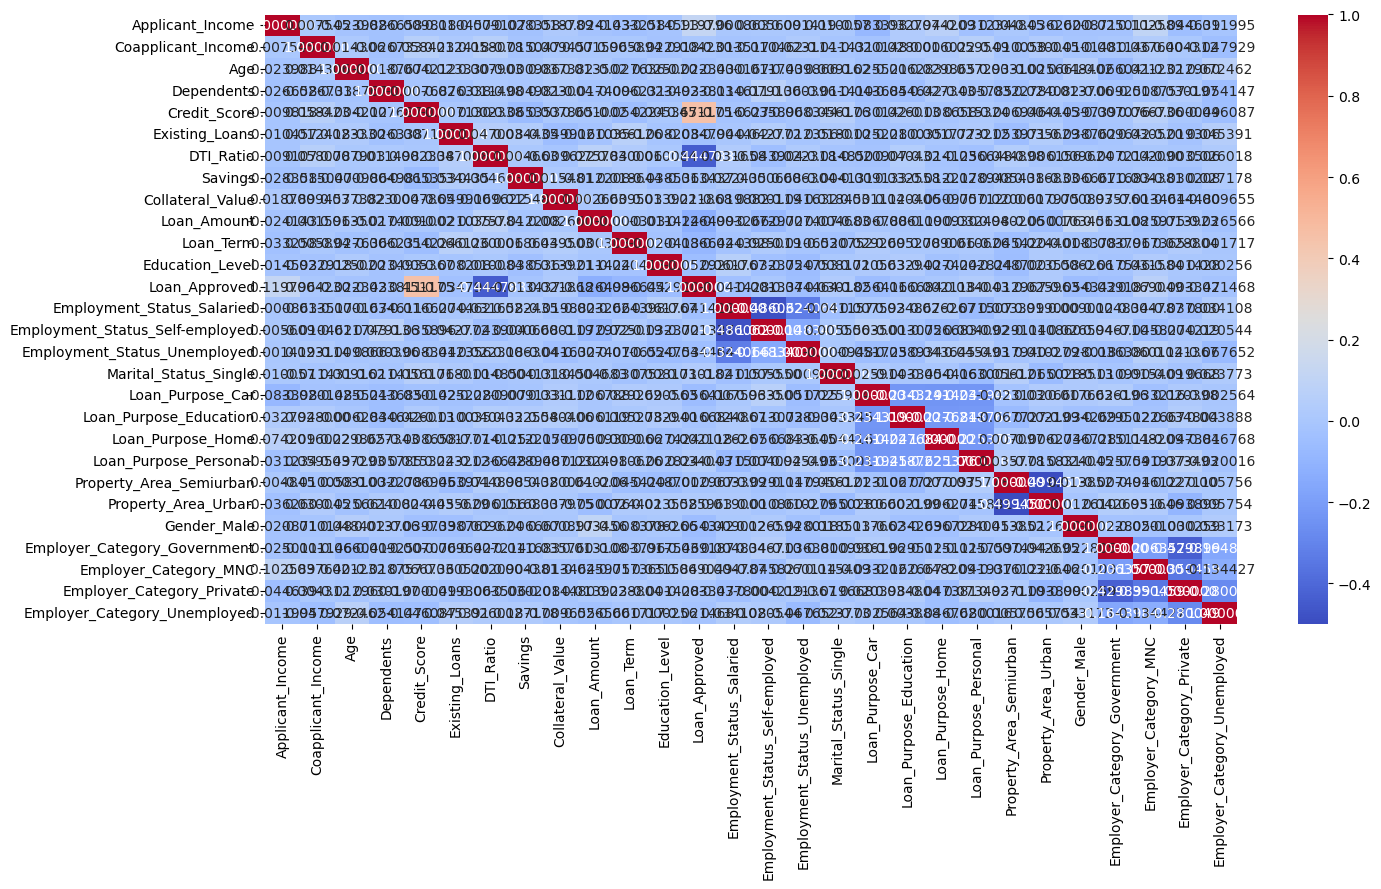

In [15]:
plt.figure(figsize=(15,9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt="2f",
    cmap="coolwarm"
)
plt.tight_layout()

# Train_Test_Split + Feature Scaling

In [20]:
X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [23]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

precision: 0.7833333333333333
Recall Score: 0.7704918032786885
Accuracy Score: 0.865
F1 Score: 0.7768595041322314
Confusion Matrix: [[126  13]
 [ 14  47]]


In [24]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

precision: 0.6274509803921569
Recall Score: 0.5245901639344263
Accuracy Score: 0.76
F1 Score: 0.5714285714285714
Confusion Matrix: [[120  19]
 [ 29  32]]


In [25]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
NB_model=GaussianNB()
NB_model.fit(X_train_scaled,y_train)
y_pred=NB_model.predict(X_test_scaled)
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

precision: 0.8035714285714286
Recall Score: 0.7377049180327869
Accuracy Score: 0.865
F1 Score: 0.7692307692307693
Confusion Matrix: [[128  11]
 [ 16  45]]


In [45]:
###### from xgboost import XGBClassifier
Xg_model=XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
Xg_model.fit(X_train_scaled,y_train)
y_pred=Xg_model.predict(X_test_scaled)
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

precision: 0.8428571428571429
Recall Score: 0.9672131147540983
Accuracy Score: 0.935
F1 Score: 0.9007633587786259
Confusion Matrix: [[128  11]
 [  2  59]]


# Feature Improving

In [33]:
df["Credit_Score_sq"]=df["Credit_Score"]**2
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
X=df.drop(columns=["Credit_Score","DTI_Ratio","Loan_Approved"])
y=df["Loan_Approved"]
X.head()
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [35]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

precision: 0.7903225806451613
Recall Score: 0.8032786885245902
Accuracy Score: 0.875
F1 Score: 0.7967479674796748
Confusion Matrix: [[126  13]
 [ 12  49]]


In [36]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)
y_pred=knn_model.predict(X_test_scaled)
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

precision: 0.62
Recall Score: 0.5081967213114754
Accuracy Score: 0.755
F1 Score: 0.5585585585585585
Confusion Matrix: [[120  19]
 [ 30  31]]


In [37]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
NB_model=GaussianNB()
NB_model.fit(X_train_scaled,y_train)
y_pred=NB_model.predict(X_test_scaled)
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

precision: 0.7833333333333333
Recall Score: 0.7704918032786885
Accuracy Score: 0.865
F1 Score: 0.7768595041322314
Confusion Matrix: [[126  13]
 [ 14  47]]


In [38]:
from xgboost import XGBClassifier
Xg_model=XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
Xg_model.fit(X_train_scaled,y_train)
y_pred=Xg_model.predict(X_test_scaled)
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
print("precision:",precision_score(y_test,y_pred))
print("Recall Score:",recall_score(y_test,y_pred))
print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))

precision: 0.8428571428571429
Recall Score: 0.9672131147540983
Accuracy Score: 0.935
F1 Score: 0.9007633587786259
Confusion Matrix: [[128  11]
 [  2  59]]
